## Import Libraries

In [59]:
import os
import zipfile
import glob
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Load and Prepare Dataframe

In [9]:
from google.colab import files
uploaded = files.upload()

zip_path = '2A.zip'
extract_path = '/content/dataset_2A'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Saving 2A.zip to 2A (2).zip
Extracted to: /content/dataset_2A


In [10]:
for root, dirs, files in os.walk(extract_path):
    print(root)

base_dir = os.path.join(extract_path, '2D', 'data')
print("Base directory:", base_dir)

/content/dataset_2A
/content/dataset_2A/2D
/content/dataset_2A/2D/data
/content/dataset_2A/2D/data/Gray_Leaf_Spot
/content/dataset_2A/2D/data/Blight
/content/dataset_2A/2D/data/Common_Rust
/content/dataset_2A/2D/data/Healthy
Base directory: /content/dataset_2A/2D/data


In [11]:
image_data = []

def extract_image_info(img_path, label):
    try:
        with Image.open(img_path) as im:
            im = im.convert('RGB')
            arr = np.array(im)

            w, h = im.size
            aspect_ratio = w / h

            return {
                'path': img_path.replace("\\", "/"),
                'label': label,
                'width': w,
                'height': h,
                'aspect_ratio': aspect_ratio,
                'r_mean': arr[:, :, 0].mean(),
                'g_mean': arr[:, :, 1].mean(),
                'b_mean': arr[:, :, 2].mean()
            }
    except Exception as e:
        print(f"Error loading {img_path}: {e}")
        return None

In [12]:
for label in os.listdir(base_dir):
    class_path = os.path.join(base_dir, label)

    if os.path.isdir(class_path):
        files = glob.glob(os.path.join(class_path, '*.*'))

        print(f"Processing class: {label} | Total: {len(files)}")

        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                info = extract_image_info(f, label)
                if info:
                    image_data.append(info)

Processing class: Gray_Leaf_Spot | Total: 574
Processing class: Blight | Total: 1146
Processing class: Common_Rust | Total: 1306
Processing class: Healthy | Total: 1162


In [16]:
df = pd.DataFrame(image_data)

print("Total data:", len(df))
df

Total data: 4188


,path,label,width,height,aspect_ratio,r_mean,g_mean,b_mean
0,/content/dataset_2A/2D/data/Gray_Leaf_Spot/Cor...,Gray_Leaf_Spot,640,480,1.333333,122.558018,132.246699,121.517161
1,/content/dataset_2A/2D/data/Gray_Leaf_Spot/Cor...,Gray_Leaf_Spot,256,256,1.000000,107.579254,117.760864,84.928253
2,/content/dataset_2A/2D/data/Gray_Leaf_Spot/Cor...,Gray_Leaf_Spot,256,256,1.000000,112.786713,113.994904,89.881668
3,/content/dataset_2A/2D/data/Gray_Leaf_Spot/Cor...,Gray_Leaf_Spot,256,256,1.000000,106.071808,110.942459,84.748291
4,/content/dataset_2A/2D/data/Gray_Leaf_Spot/Cor...,Gray_Leaf_Spot,256,256,1.000000,127.971069,132.943649,103.868790
...,...,...,...,...,...,...,...,...
4183,/content/dataset_2A/2D/data/Healthy/Corn_Healt...,Healthy,256,256,1.000000,112.683640,161.285477,133.382462
4184,/content/dataset_2A/2D/data/Healthy/Corn_Healt...,Healthy,256,256,1.000000,148.919464,180.651199,125.192169
4185,/content/dataset_2A/2D/data/Healthy/Corn_Healt...,Healthy,256,256,1.000000,148.880905,176.652756,133.468994
4186,/content/dataset_2A/2D/data/Healthy/Corn_Healt...,Healthy,256,256,1.000000,133.932404,172.209305,154.153412


Ditemukan :
- **resolusi gambar tidak konsisten (256x256, 640x480)** sehingga harus dilakukan resize.
- **aspect_ratio tidak seragam** ada yang bernilai 1.0 (square) dan ada juga yang bernilai 1.33 (rectangular)

## EDA

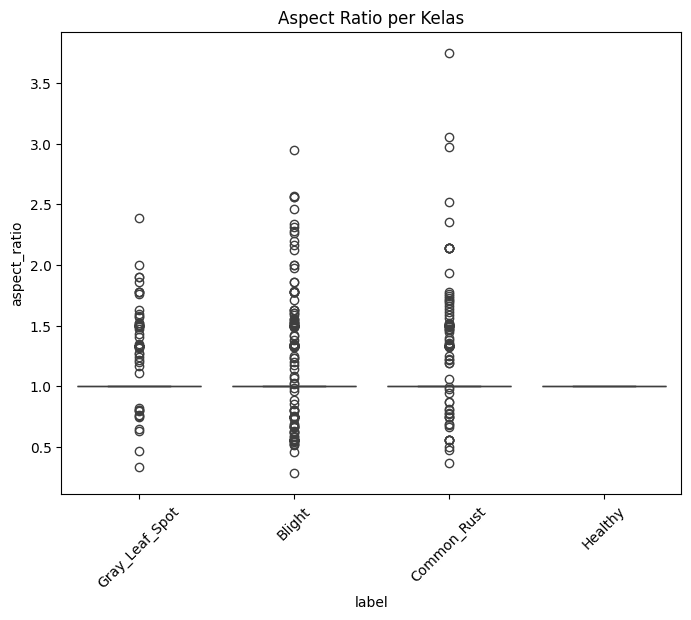

In [26]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='aspect_ratio')
plt.title('Aspect Ratio per Kelas')
plt.xticks(rotation=45)
plt.show()

Sebagian besar gambar memiliki **aspect ratio mendekati 1**, namun terdapat variasi yang menunjukkan bahwa ukuran gambar **tidak seragam**.

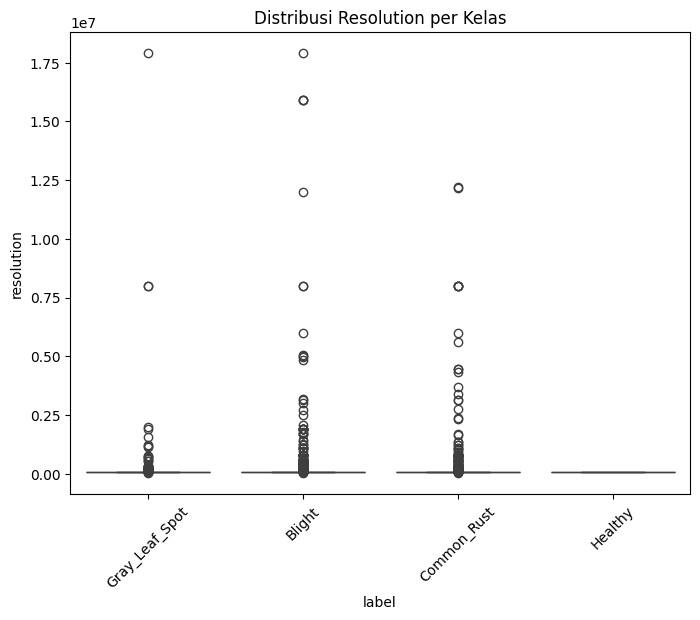

In [27]:
df['resolution'] = df['width'] * df['height']

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='resolution')
plt.title('Distribusi Resolution per Kelas')
plt.xticks(rotation=45)
plt.show()

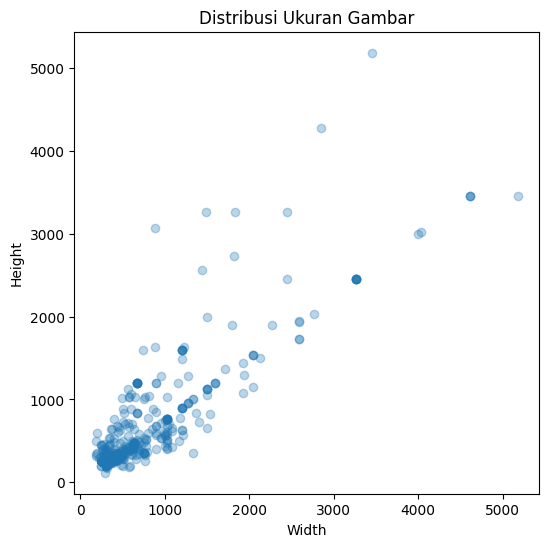

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(df['width'], df['height'], alpha=0.3)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Distribusi Ukuran Gambar')
plt.show()

**Resolusi gambar bervariasi** antar kelas, dengan **sebagian besar berada pada ukuran 256×256**, namun terdapat beberapa gambar dengan resolusi lebih tinggi.

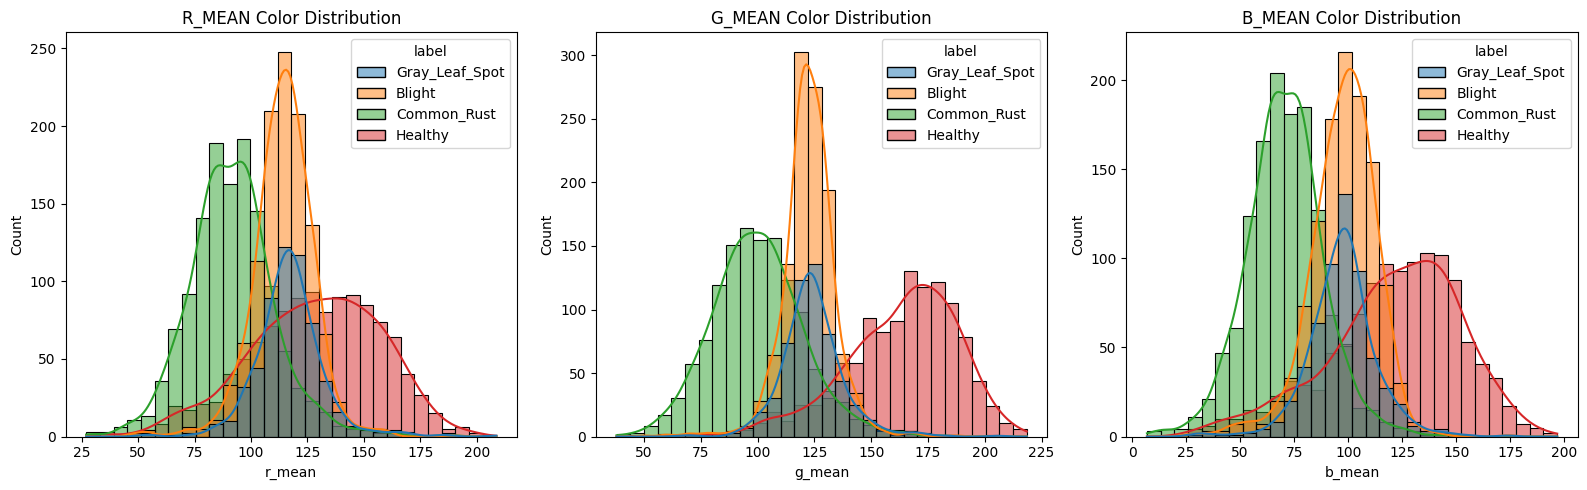

In [31]:
plt.figure(figsize=(16, 5))
for i, channel in enumerate(['r_mean', 'g_mean', 'b_mean']):
    plt.subplot(1, 3, i+1)
    sns.histplot(data=df, x=channel, hue='label', kde=True, bins=30)
    plt.title(f'{channel.upper()} Color Distribution')

plt.tight_layout()
plt.show()

Distribusi warna menunjukkan bahwa **kanal hijau (G) mendominasi** pada seluruh kelas, yang sesuai dengan karakteristik daun. Namun memang terdapat **perbedaan distribusi antar kelas**.

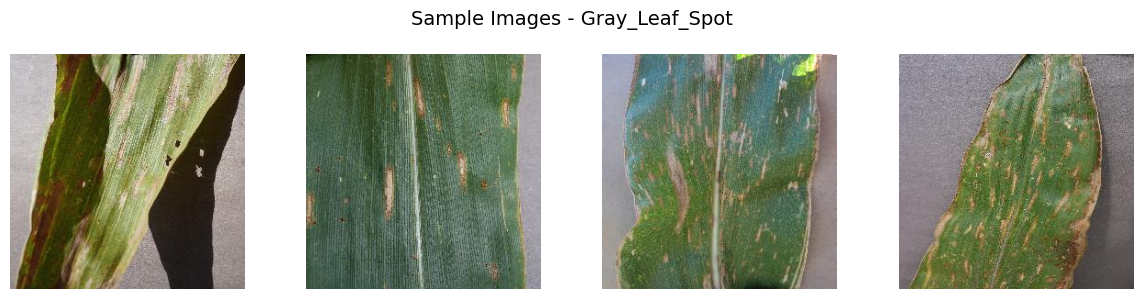

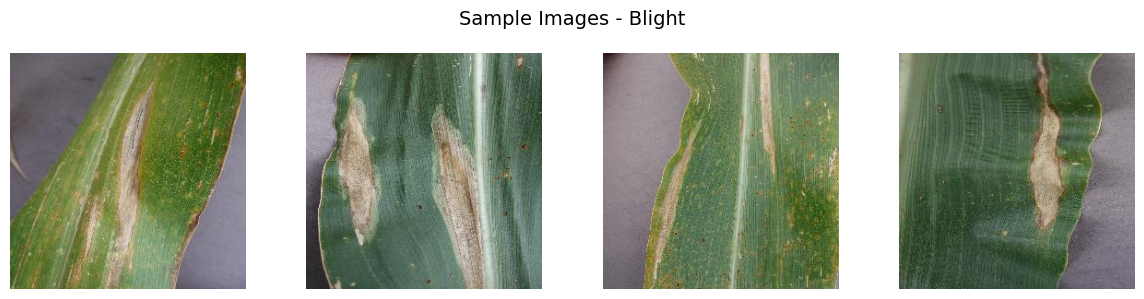

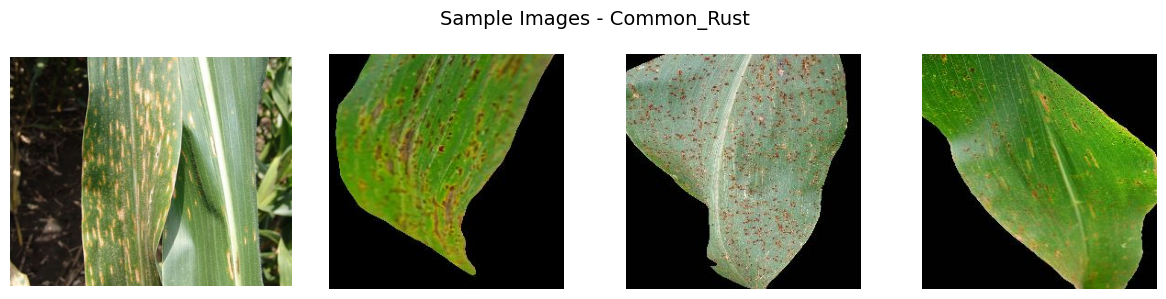

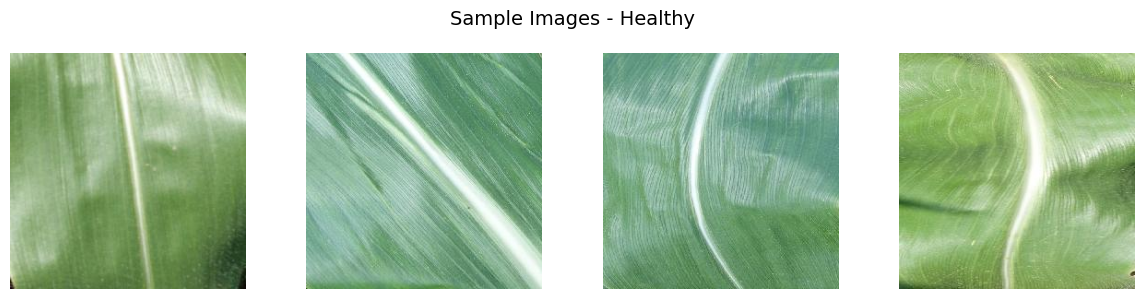

In [30]:
def plot_sample_images(df, label, n=4):
    sample_paths = df[df['label'] == label]['path'].sample(n, random_state=42).values
    fig, axs = plt.subplots(1, n, figsize=(12, 3))
    fig.suptitle(f'Sample Images - {label}', fontsize=14)

    for i, img_path in enumerate(sample_paths):
        img = Image.open(img_path)
        axs[i].imshow(img)
        axs[i].axis('off')

    plt.tight_layout()
    plt.show()

# Loop semua label
for label in df['label'].unique():
    plot_sample_images(df, label, n=4)

In [32]:
print("Total gambar:", len(df))
print("\nJumlah kelas:", df['label'].nunique())
print("\nDistribusi kelas:")
print(df['label'].value_counts())

Total gambar: 4188

Jumlah kelas: 4

Distribusi kelas:
label
Common_Rust       1306
Healthy           1162
Blight            1146
Gray_Leaf_Spot     574
Name: count, dtype: int64


Dataset tidak seimbang (**class imbalance**). Class **Gray_Leaf_Spot** jumlahnya jauh lebih sedikit dibandingkan kategori lainnya.

## Splitting Data

In [34]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print("Jumlah data:")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

Jumlah data:
Train      : 2931
Validation : 628
Test       : 629


In [35]:
print("\nDistribusi Train:")
print(train_df['label'].value_counts())

print("\nDistribusi Validation:")
print(val_df['label'].value_counts())

print("\nDistribusi Test:")
print(test_df['label'].value_counts())


Distribusi Train:
label
Common_Rust       914
Healthy           813
Blight            802
Gray_Leaf_Spot    402
Name: count, dtype: int64

Distribusi Validation:
label
Common_Rust       196
Healthy           174
Blight            172
Gray_Leaf_Spot     86
Name: count, dtype: int64

Distribusi Test:
label
Common_Rust       196
Healthy           175
Blight            172
Gray_Leaf_Spot     86
Name: count, dtype: int64


## Preprocessing

In [38]:
image_size = (224, 224)
batch_size = 16

In [39]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=15,
                                   horizontal_flip=True,
                                   zoom_range=0.1)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [40]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=image_size,
    class_mode='categorical',
    batch_size=batch_size
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=image_size,
    class_mode='categorical',
    batch_size=batch_size
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=image_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

Found 2931 validated image filenames belonging to 4 classes.
Found 628 validated image filenames belonging to 4 classes.
Found 629 validated image filenames belonging to 4 classes.


In [41]:
class_names = list(train_generator.class_indices.keys())
print("Class labels:", class_names)

Class labels: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


## Baseline Model (AlexNet)

In [43]:
num_classes = 4
input_shape = (224, 224, 3)

model = models.Sequential()

model.add(layers.Conv2D(96, kernel_size=11, strides=4, activation='relu', input_shape=input_shape))
model.add(layers.MaxPooling2D(pool_size=3, strides=2))

model.add(layers.Conv2D(256, kernel_size=5, padding='same', activation='relu'))
model.add(layers.MaxPooling2D(pool_size=3, strides=2))

model.add(layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'))

model.add(layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'))

model.add(layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'))
model.add(layers.MaxPooling2D(pool_size=3, strides=2))

model.add(layers.Flatten())

model.add(layers.Dense(4096, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(4096, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,763,396 (178.39 MB)

 Trainable params: 46,763,396 (178.39 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 59s 273ms/step - accuracy: 0.5179 - loss: 1.1254 - val_accuracy: 0.5016 - val_loss: 0.9929
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - accuracy: 0.4845 - loss: 1.3311 - val_accuracy: 0.4506 - val_loss: 1.0985
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 236ms/step - accuracy: 0.3364 - loss: 1.5775 - val_accuracy: 0.3121 - val_loss: 1.3529
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - accuracy: 0.3030 - loss: 1.3517 - val_accuracy: 0.3121 - val_loss: 1.3480
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - accuracy: 0.3033 - loss: 1.3498 - val_accuracy: 0.3121 - val_loss: 1.3470
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 238ms/step - accuracy: 0.3088 - loss: 1.3511 - val_accuracy: 0.3121 - val_loss: 1.3482
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 238ms/step - accuracy: 0.3101 - loss: 1.3503 - val_accuracy: 0.3121 - val_loss: 1.3462
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - accuracy: 0.3098 - loss: 1

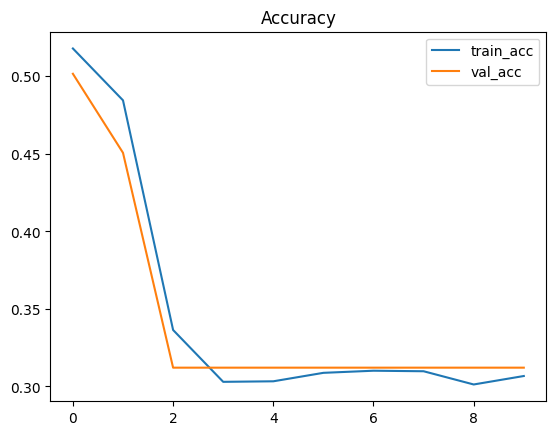

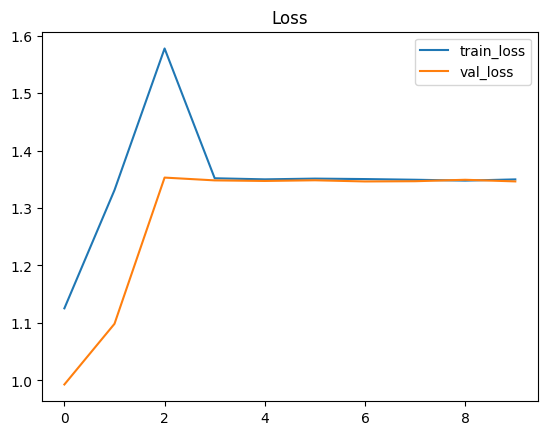

In [45]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.show()

Hasil training menunjukkan bahwa **model AlexNet baseline tidak mampu belajar dengan baik**. **Setelah epoch pertama, performa model menurun** dan stabil pada akurasi sekitar 31%, yang mendekati performa random guessing untuk 4 kelas. Hal ini menunjukkan model mengalami kesulitan dalam konvergensi dan arsitektur terlalu kompleks untuk dataset yang tersedia.

## Modified Baseline Model

In [48]:
num_classes = 4
input_shape = (224, 224, 3)

model_improved = models.Sequential()

model_improved.add(layers.Conv2D(96, kernel_size=11, strides=4, padding='same', input_shape=input_shape))
model_improved.add(layers.BatchNormalization())
model_improved.add(layers.Activation('relu'))
model_improved.add(layers.MaxPooling2D(pool_size=3, strides=2))

model_improved.add(layers.Conv2D(256, kernel_size=5, padding='same'))
model_improved.add(layers.BatchNormalization())
model_improved.add(layers.Activation('relu'))
model_improved.add(layers.MaxPooling2D(pool_size=3, strides=2))

model_improved.add(layers.Conv2D(384, kernel_size=3, padding='same'))
model_improved.add(layers.BatchNormalization())
model_improved.add(layers.Activation('relu'))

model_improved.add(layers.Conv2D(384, kernel_size=3, padding='same'))
model_improved.add(layers.BatchNormalization())
model_improved.add(layers.Activation('relu'))

model_improved.add(layers.Conv2D(256, kernel_size=3, padding='same'))
model_improved.add(layers.BatchNormalization())
model_improved.add(layers.Activation('relu'))
model_improved.add(layers.MaxPooling2D(pool_size=3, strides=2))

model_improved.add(layers.Flatten())

model_improved.add(layers.Dense(4096))
model_improved.add(layers.BatchNormalization())
model_improved.add(layers.Activation('relu'))
model_improved.add(layers.Dropout(0.5))

model_improved.add(layers.Dense(4096))
model_improved.add(layers.BatchNormalization())
model_improved.add(layers.Activation('relu'))
model_improved.add(layers.Dropout(0.5))

model_improved.add(layers.Dense(num_classes, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model_improved.compile(optimizer=optimizer,
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

In [49]:
history_improved = model_improved.fit(train_generator,
                                      validation_data=val_generator,
                                      epochs=15,
                                      callbacks=[early_stop])

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 68s 295ms/step - accuracy: 0.7728 - loss: 0.6841 - val_accuracy: 0.3089 - val_loss: 2.9579
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 45s 244ms/step - accuracy: 0.8253 - loss: 0.5358 - val_accuracy: 0.5796 - val_loss: 1.9915
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 239ms/step - accuracy: 0.8506 - loss: 0.4307 - val_accuracy: 0.6815 - val_loss: 1.0589
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 241ms/step - accuracy: 0.8618 - loss: 0.4318 - val_accuracy: 0.8583 - val_loss: 0.3880
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 236ms/step - accuracy: 0.8744 - loss: 0.3537 - val_accuracy: 0.6959 - val_loss: 0.9493
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 240ms/step - accuracy: 0.8751 - loss: 0.3716 - val_accuracy: 0.8264 - val_loss: 0.4842
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 241ms/step - accuracy: 0.8850 - loss: 0.3213 - val_accuracy: 0.6720 - val_loss: 0.7141


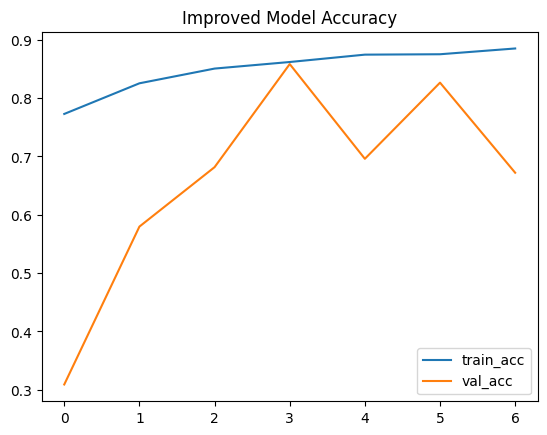

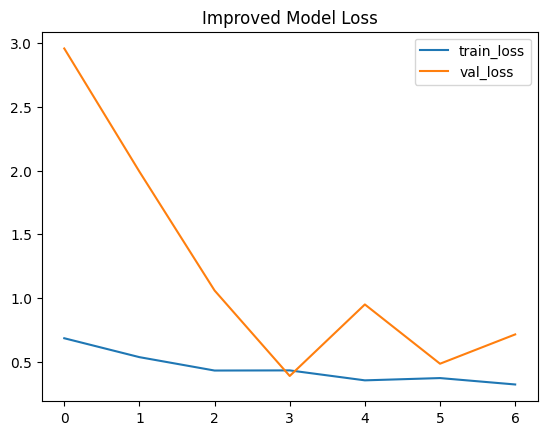

In [50]:
plt.plot(history_improved.history['accuracy'], label='train_acc')
plt.plot(history_improved.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Improved Model Accuracy')
plt.show()

plt.plot(history_improved.history['loss'], label='train_loss')
plt.plot(history_improved.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Improved Model Loss')
plt.show()

Model hasil modifikasi menunjukkan **peningkatan performa yang signifikan dibandingkan baseline**. **Akurasi training meningkat hingga sekitar 88%**, sementara **akurasi validation mencapai nilai tertinggi sekitar 85%**.

Namun, performa validation menunjukkan fluktuasi antar epoch, yang **mengindikasikan adanya overfitting ringan serta ketidakstabilan selama proses training**. Hal ini kemungkinan disebabkan oleh ukuran dataset yang relatif terbatas dibandingkan kompleksitas model.

## Model EfficientNet

In [53]:
def conv_block(x, filters, kernel_size=3, strides=1):
    x = DepthwiseConv2D(kernel_size=kernel_size, strides=strides, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, kernel_size=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    return x

def simple_effnet_like(input_shape=(224, 224, 3), num_classes=4):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, 3, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = conv_block(x, 64)
    x = conv_block(x, 128, strides=2)
    x = conv_block(x, 128)
    x = conv_block(x, 256, strides=2)
    x = conv_block(x, 256)

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

modif_model = simple_effnet_like()

modif_model.compile(optimizer=Adam(learning_rate=0.0003),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

early_stop = EarlyStopping(patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=2, factor=0.3)

history_effnet = modif_model.fit(train_generator,
                                 validation_data=val_generator,
                                 epochs=15,
                                 callbacks=[early_stop, reduce_lr])

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 94s 375ms/step - accuracy: 0.7448 - loss: 0.6862 - val_accuracy: 0.2739 - val_loss: 2.0077 - learning_rate: 3.0000e-04
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - accuracy: 0.7888 - loss: 0.5380 - val_accuracy: 0.2771 - val_loss: 3.7368 - learning_rate: 3.0000e-04
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 231ms/step - accuracy: 0.8308 - loss: 0.4221 - val_accuracy: 0.4825 - val_loss: 3.6155 - learning_rate: 3.0000e-04
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 233ms/step - accuracy: 0.8451 - loss: 0.4071 - val_accuracy: 0.8408 - val_loss: 0.4222 - learning_rate: 9.0000e-05
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 233ms/step - accuracy: 0.8564 - loss: 0.3694 - val_accuracy: 0.8678 - val_loss: 0.3770 - learning_rate: 9.0000e-05
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 232ms/step - accuracy: 0.8622 - loss: 0.3541 - val_accuracy: 0.8567 - val_loss: 0.3561 - learning_rate: 9.0000e-05
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 42s 23

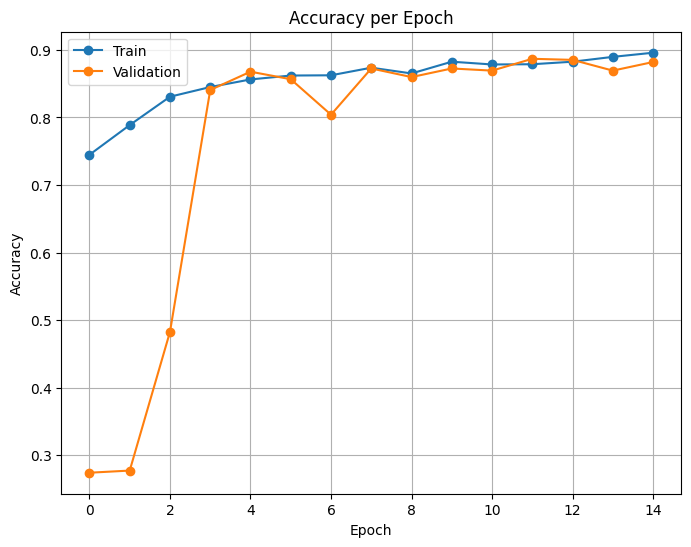

In [54]:
plt.figure(figsize=(8,6))
plt.plot(history_effnet.history['accuracy'], marker='o')
plt.plot(history_effnet.history['val_accuracy'], marker='o')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

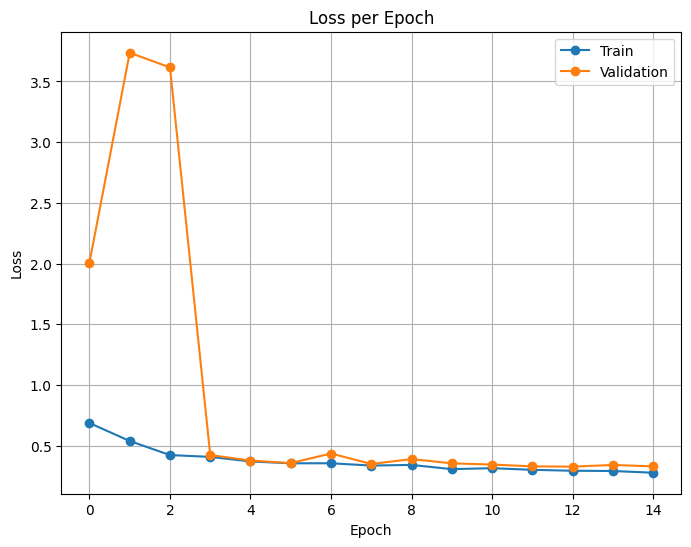

In [55]:
plt.figure(figsize=(8,6))
plt.plot(history_effnet.history['loss'], marker='o')
plt.plot(history_effnet.history['val_loss'], marker='o')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

**Model EfficientNet-like menunjukkan performa yang sangat baik** dibandingkan dengan model baseline AlexNet. **Akurasi training mencapai sekitar 89%, sementara akurasi validation stabil di sekitar 88%**.

Perbedaan antara akurasi training dan validation yang sangat kecil menunjukkan bahwa model memiliki **kemampuan generalisasi yang baik dan tidak mengalami overfitting**.

Selain itu, penggunaan teknik seperti **depthwise separable convolution, batch normalization, serta learning rate scheduling terbukti meningkatkan stabilitas dan performa model secara signifikan**.

Model dengan arsitektur yang lebih ringan dan efisien terbukti lebih cocok untuk dataset berukuran sedang dibandingkan arsitektur klasik seperti AlexNet yang memiliki jumlah parameter sangat besar.

## Evaluation Model

In [56]:
test_loss, test_acc = modif_model.evaluate(test_generator)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - accuracy: 0.9237 - loss: 0.2229

Test Loss: 0.2229
Test Accuracy: 0.9237


In [57]:
pred_probs = modif_model.predict(test_generator)
pred_labels = np.argmax(pred_probs, axis=1)

true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())
print(class_names)

40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step
['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


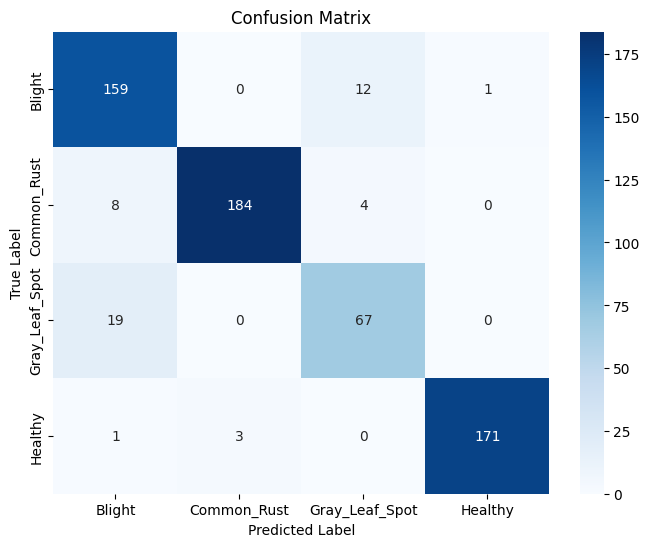

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [61]:
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=class_names))


Classification Report:

                precision    recall  f1-score   support

        Blight       0.85      0.92      0.89       172
   Common_Rust       0.98      0.94      0.96       196
Gray_Leaf_Spot       0.81      0.78      0.79        86
       Healthy       0.99      0.98      0.99       175

      accuracy                           0.92       629
     macro avg       0.91      0.90      0.91       629
  weighted avg       0.93      0.92      0.92       629



Berdasarkan **hasil evaluasi pada data test, model CNN yang dikembangkan mampu mencapai akurasi sebesar 92.37%**, yang menunjukkan performa klasifikasi yang sangat baik.

Model memiliki kemampuan **generalisasi yang baik, terlihat dari keseimbangan antara precision, recall, dan F1-score** pada sebagian besar kelas. Kelas Healthy dan Common Rust menunjukkan performa yang sangat tinggi, sedangkan kelas Gray Leaf Spot memiliki performa paling rendah.

Secara keseluruhan, **model EfficientNet-like terbukti lebih efektif dibandingkan arsitektur AlexNet dalam menangani dataset ini**.

Untuk **meningkatkan performa model di masa mendatang**, dapat dilakukan beberapa pengembangan yaitu :   
- **Penambahan jumlah dataset**, khususnya pada kelas **Gray Leaf Spot**
- Penerapan **teknik data augmentation** yang lebih kompleks seperti penyesuaian brightness, contrast, serta random cropping dapat meningkatkan variasi data dan membantu model menjadi lebih robust terhadap kondisi gambar yang beragam.
- Penggunaan **metode transfer learning** dengan memanfaatkan model pre-trained seperti EfficientNet atau ResNet juga dapat dipertimbangkan untuk meningkatkan akurasi secara signifikan.
- **Hyperparameter tuning dengan mencoba berbagai kombinasi** learning rate, batch size, dan optimizer untuk menemukan konfigurasi terbaik bagi model.
- **Pendekatan model ensemble**, yaitu menggabungkan beberapa model, dapat digunakan untuk meningkatkan performa keseluruhan dengan memanfaatkan keunggulan masing-masing model.